# X2: EMRIs, the LISA response & TDI, and a standalone EMRI MCMC

**Development-stack exercise notebook (LATW `dev` branch).** There is no
Colab button: these exercises target the *development* versions of the LISA
Analysis Tools packages. Set the environment up by cloning LISAanalysistools
and running its installer (it lays every sibling repo out side by side and
editable-installs the development branches):

```bash
git clone https://github.com/lisa-analysis-tools/lisa-analysis-tools.git LISAanalysistools
bash LISAanalysistools/install.sh
```

For the workshop on the **pip-released** packages, use the
[`main` branch](https://github.com/lisa-analysis-tools/LATW/tree/main) instead
(branch policy: `main` &harr; pip releases, `dev` &harr; the `install.sh` stack).

In [1]:
import os

# Threading is pinned to 1 everywhere in this workshop (MPI-only policy;
# OMP-threaded kernels have caused out-of-memory kills on laptops).
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")

import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from copy import deepcopy
from lisatools.utils.constants import *

# Eryn's internals still import a legacy prior module (harmless) and the stock
# noise models divide by f = 0 on full grids; silence both so output stays clean.
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

This notebook follows an **extreme mass-ratio inspiral (EMRI)** from a raw
waveform all the way to a **posterior** &mdash; the same journey
[`X6`](X6_GalacticBinaryMCMC.ipynb) made for a galactic binary, now for a very
different source. An EMRI is a stellar-mass compact object (~10 M&#8857;)
spiralling through ~10&#8309; orbits into a massive black hole (~10&#8310;
M&#8857;); its waveform is a long, intricate, many-harmonic signal that finely
maps the Kerr spacetime. We will

1. **generate** a short EMRI with the stock, global-fit-aligned
   `EMRITDIWaveform` and look at its **XYZ TDI** channels;
2. see how the two GW polarizations $h_+,h_\times$ become XYZ TDI through the
   **LISA response**, and score the EMRI's **SNR** with the `AnalysisContainer`
   from [`X1`](X1_SensitivitySNR.ipynb); and
3. run a small **standalone EMRI MCMC** &mdash; the very source-MCMC skeleton
   from [`X6`](X6_GalacticBinaryMCMC.ipynb) with the waveform swapped out.

The companion informational notebooks are [`03`](../../03_ResponseAndTDI.ipynb)
(the LISA response & TDI), [`04`](../../04_SourceWaveforms.ipynb) (the EMRI
waveform), and [`05`](../../05_ErynSmallToLarge.ipynb) (Eryn). Everything is in
the **XYZ** TDI basis, on the laptop CPU. Because EMRI templates are *expensive*
(each is a full multi-harmonic waveform put through the response), every step is
kept deliberately short.

### How these exercises work

Each exercise is one of two kinds:

- **Task N** &mdash; you *write code* toward a stated goal. In this answer notebook the
  solution cells are filled in; in the generated student notebook they are blanked
  (a whole cell, or just the key solution lines for a fill-in-the-blank). Every
  Task ends with a **Useful documentation:** list pointing at the Sphinx/Eryn API
  docs and the relevant informational-notebook section.
- **Question** (a `### Question` heading) &mdash; a short *discussion* prompt. No code
  required; the answer sketch here is for the group conversation and is removed in
  the student notebook.

The tasks build on each other in order, so run them top to bottom.

### The same source-MCMC skeleton

[`X6`](X6_GalacticBinaryMCMC.ipynb) showed that every source in the LISA global
fit is sampled with the **same skeleton**. This notebook reuses it verbatim for an
EMRI &mdash; only the waveform changes:

- **Stage A &mdash; Data** (Task 1): an injected data stream from a waveform
  generator (here a *synthetic* EMRI in XYZ on a short grid).
- **Stage B &mdash; Template generator** (Task 3): a `signal_gen(*params) -> DomainBase`
  closure that builds a band-limited template.
- **Stage C &mdash; Likelihood** (Task 3): an `AnalysisContainer(data, sens, signal_gen)`
  whose `eryn_likelihood_function` is the sampler's log-likelihood.
- **Stage D &mdash; Sample** (Task 3): Eryn priors + a tempered `EnsembleSampler`, a
  short run, a corner plot against the truth.

An EMRI is *the same sampler with a different `signal_gen`* &mdash; but its waveform
is far costlier and its likelihood far sharper than a GB's, which is why the run
here is tiny and explicitly **not converged**.

## Task 1: Build a short EMRI waveform and plot its XYZ TDI channels (Stage A)

Every analysis starts from a **data stream**. Here we synthesize one: a single
EMRI injected into empty (noiseless) XYZ data on a short grid, so we know the truth
exactly. The stock, global-fit-aligned waveform is
[`EMRITDIWaveform`](../../04_SourceWaveforms.ipynb) (`lisatools.sources.emri`),
which delegates to the fit's `get_emri_response_wrapper`: FEW
`FastKerrEccentricEquatorialFlux` intrinsic model, 2nd-generation TDI, **XYZ**
channels, response `order=40`, `remove_garbage="zero"` &mdash; the *same* generator
the `all_sources` global fit uses for its EMRI branch.

The cell that builds the EMRI and generates its response is **provided**; run it
as-is (it takes ~1 min &mdash; building the response and the first waveform are the
expensive one-time costs). Your task is the next cell: **plot** the three XYZ TDI
channels in the time domain and the X channel's amplitude spectrum.

Useful documentation:
* [`EMRITDIWaveform`](https://mikekatz04.github.io/LISAanalysistools/build/html/user/main.html) (the stock EMRI TDI waveform; see [`04` &sect; EMRI](../../04_SourceWaveforms.ipynb))
* [`TDSignal`](https://mikekatz04.github.io/LISAanalysistools/build/html/user/domains.html#lisatools.domains.TDSignal) /
  [`TDSettings`](https://mikekatz04.github.io/LISAanalysistools/build/html/user/domains.html#lisatools.domains.TDSettings)
* Informational notebooks: see [`04` &sect; EMRI](../../04_SourceWaveforms.ipynb) and [`03` &sect; Response](../../03_ResponseAndTDI.ipynb)

In [2]:
# imports
from lisatools.sources.emri import EMRITDIWaveform
from lisatools.domains import TDSignal, TDSettings, FDSignal, FDSettings

In [3]:
# provided ("the data processor"): build the EMRI + its XYZ TDI response. Run as-is.
dt = 20.0        # cadence [s]  (modest; Nyquist 1/(2 dt) = 0.025 Hz covers the EMRI band)
T = 0.1          # observation span [yr]  (~37 days -- short + laptop-cheap)

# stock, global-fit-aligned EMRI TDI waveform (FastKerrEccentricEquatorialFlux,
# 2nd-gen TDI, XYZ, response order 40, remove_garbage="zero").
emri = EMRITDIWaveform(T=T, dt=dt, t0=0.0, force_backend="cpu")

# FEW 14-parameter basis:
#   [M, mu, a, p0, e0, xI0, dist(Gpc), qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
# We only *sample* (M, mu, Phi_phi0) later; the rest are held fixed at truth.
M, mu, a, p0, e0, xI0, dist = 1.0e6, 10.0, 0.5, 12.0, 0.3, 1.0, 1.0
qS, phiS, qK, phiK = 0.8, 2.0, 1.5, 1.2
Phi_phi0, Phi_theta0, Phi_r0 = 1.0, 2.0, 3.0
truth14 = [M, mu, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
           Phi_phi0, Phi_theta0, Phi_r0]

# (3, N) XYZ TDI response (LDC time-domain convention).
chans = np.asarray([np.asarray(c) for c in emri(*truth14)])
N = chans.shape[-1]
print("XYZ TDI shape:", chans.shape, "  Tobs =", round(N * dt / 86400.0, 1), "days")

XYZ TDI shape: (3, 157790)   Tobs = 36.5 days


Now plot the injection. Show the three XYZ TDI channels over the first day (to
see the response modulation) and the X channel's amplitude spectrum $\sqrt f\,
|\tilde X(f)|$ (to see the many-harmonic frequency content).

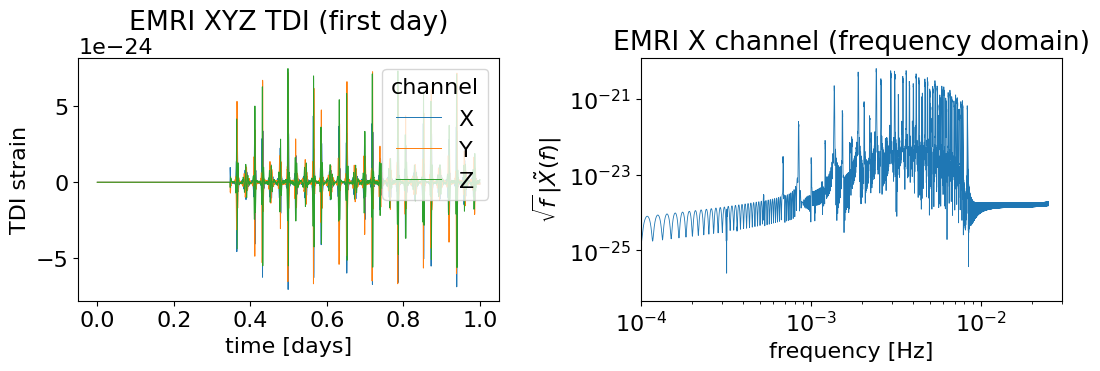

In [4]:
# clear
tt = np.arange(N) * dt / 86400.0             # time [days]
zoom = tt < 1.0                              # first day

fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4))
for lab, i, col in zip("XYZ", range(3), ("C0", "C1", "C2")):
    a0.plot(tt[zoom], chans[i][zoom], color=col, lw=0.7, label=lab)
a0.set(xlabel="time [days]", ylabel="TDI strain",
       title="EMRI XYZ TDI (first day)")
a0.legend(title="channel")

# amplitude spectrum of the X channel (LDC FD convention: FD = dt * rfft(td))
freqs = np.fft.rfftfreq(N, dt)
Xf = dt * np.fft.rfft(chans[0])
a1.loglog(freqs, np.sqrt(freqs) * np.abs(Xf), color="C0", lw=0.6)
a1.set(xlabel="frequency [Hz]", ylabel=r"$\sqrt{f}\,|\tilde X(f)|$",
       xlim=(1e-4, 3e-2), title="EMRI X channel (frequency domain)")
fig.tight_layout()
plt.show()

### Question: why does the EMRI waveform look like that?

The time series is a slowly evolving, amplitude- and frequency-modulated
"chirp-with-structure", and the spectrum is a dense comb of harmonics. Decode this
in terms of the compact object's orbit.

*Discussion.* An EMRI is a small body on a *generic Kerr geodesic*, so its orbit
carries **three independent frequencies** &mdash; radial (from the eccentricity
$e_0$), polar, and azimuthal (with relativistic *periastron* and *Lense-Thirring*
precession from the spin $a$). The GW power comes out at integer combinations of
those frequencies, which is why the spectrum is a rich **comb of harmonics** rather
than a single line: a moderately eccentric EMRI radiates in dozens of modes at once.
As the body inspirals over the observation, all of these frequencies **sweep upward**
(radiation reaction shrinks and circularizes the orbit), so each harmonic drifts and
the whole pattern slowly chirps. On top of that intrinsic structure, the ~1-day
modulation you see in the time domain is the **LISA response** (Task 2): the orbiting
constellation's antenna pattern sweeps across the source. Because the phasing of all
those harmonics is set by the strong-field geometry, an EMRI encodes the masses,
spin, and orbit to extraordinary precision &mdash; the flip side (Task 3) is that
the likelihood is correspondingly sharp.

## Task 2: The LISA response & TDI, and the EMRI SNR

What `EMRITDIWaveform` actually did in Task 1 was wrap the intrinsic FEW
waveform in the **LISA response**. The intrinsic waveform is just the two GW
polarizations $h_+(t)$ and $h_\times(t)$ in the solar-system frame. The
[`ResponseWrapper`](https://mikekatz04.github.io/LISAanalysistools/build/html/user/main.html)
(see [`03`](../../03_ResponseAndTDI.ipynb)) turns them into what LISA *measures*:
it projects $h_+,h_\times$ onto each moving laser link (with the light-travel-time
delays along the arms), then forms the **Time-Delay Interferometry (TDI)**
combinations $X,Y,Z$ that cancel the otherwise-overwhelming laser frequency noise.
Those three XYZ channels &mdash; the ones you plotted &mdash; are the data. Below,
the **provided** cell regenerates the bare $h_+,h_\times$ (via FEW directly) so you
can see the polarizations *before* the response, next to the XYZ TDI *after* it.

Then your task: score the injection's **optimal SNR**. Band-limit the XYZ data into
an [`FDSignal`](https://mikekatz04.github.io/LISAanalysistools/build/html/user/domains.html#lisatools.domains.FDSignal),
pair it with an
[`XYZ2SensitivityMatrix`](https://mikekatz04.github.io/LISAanalysistools/build/html/user/sensitivity.html#lisatools.sensitivity.XYZ2SensitivityMatrix)
(the 3&times;3 XYZ noise covariance), drop both into an
[`AnalysisContainer`](https://mikekatz04.github.io/LISAanalysistools/build/html/user/datacontainer.html#analysis-container)
&mdash; the analysis atom from [`X1`](X1_SensitivitySNR.ipynb) &mdash; and read off
`.snr()`.

Useful documentation:
* [`XYZ2SensitivityMatrix`](https://mikekatz04.github.io/LISAanalysistools/build/html/user/sensitivity.html#lisatools.sensitivity.XYZ2SensitivityMatrix) /
  [`AnalysisContainer`](https://mikekatz04.github.io/LISAanalysistools/build/html/user/datacontainer.html#analysis-container) / [`.snr`](https://mikekatz04.github.io/LISAanalysistools/build/html/user/datacontainer.html#lisatools.analysiscontainer.AnalysisContainer.snr)
* [`FDSignal`](https://mikekatz04.github.io/LISAanalysistools/build/html/user/domains.html#lisatools.domains.FDSignal) /
  [`FDSettings`](https://mikekatz04.github.io/LISAanalysistools/build/html/user/domains.html#lisatools.domains.FDSettings)
* Informational notebooks: see [`03` &sect; Response](../../03_ResponseAndTDI.ipynb) and [`X1`](X1_SensitivitySNR.ipynb)

In [5]:
# imports
from few.waveform import GenerateEMRIWaveform
from lisatools.sensitivity import XYZ2SensitivityMatrix
from lisatools.analysiscontainer import AnalysisContainer

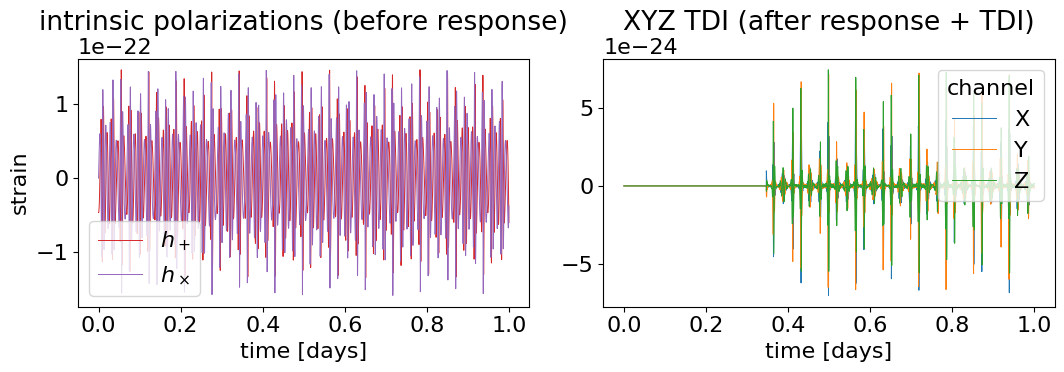

In [6]:
# provided: the *bare* polarizations h+, hx (before the response) vs the XYZ TDI
# (after it). Run as-is. (The FEW modules are already warm from Task 1, so this
# second generator is cheap.)
few_gen = GenerateEMRIWaveform("FastKerrEccentricEquatorialFlux",
                               return_list=True, frame="detector",
                               force_backend="cpu")
hp, hx = (np.asarray(w) for w in few_gen(*truth14, T=T, dt=dt))

tt_p = np.arange(hp.size) * dt / 86400.0
zp = tt_p < 1.0
fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
a0.plot(tt_p[zp], hp[zp], "C3", lw=0.7, label=r"$h_+$")
a0.plot(tt_p[zp], hx[zp], "C4", lw=0.7, label=r"$h_\times$")
a0.set(xlabel="time [days]", ylabel="strain",
       title="intrinsic polarizations (before response)")
a0.legend()
for lab, i, col in zip("XYZ", range(3), ("C0", "C1", "C2")):
    a1.plot(tt[zoom], chans[i][zoom], color=col, lw=0.7, label=lab)
a1.set(xlabel="time [days]", title="XYZ TDI (after response + TDI)")
a1.legend(title="channel")
fig.tight_layout()
plt.show()

Now score the injection's SNR. Band-limit the XYZ data to the EMRI's band
(it lives below ~20 mHz), build the matching `XYZ2SensitivityMatrix`, and read off
the optimal SNR from the `AnalysisContainer`.

In [7]:
# clear
band = (1.0e-3, 2.0e-2)                       # the EMRI's frequency support
df = 1.0 / (N * dt)                           # frequency resolution
td_set = TDSettings(N=N, dt=dt, force_backend="cpu")

# XYZ data on the full rFFT grid (LDC convention FD = dt * rfft), band-limited
fd_full = TDSignal(chans, td_set).fft()
fd_band = FDSettings(N=N // 2 + 1, df=df, min_freq=band[0], max_freq=band[1],
                     force_backend="cpu")
data = FDSignal(np.asarray(fd_full.arr).copy(), fd_band)     # auto-sliced to band
sens = XYZ2SensitivityMatrix(fd_band, model="sangria")       # 3x3 XYZ covariance

ac_data = AnalysisContainer(data, sens)                      # the analysis atom (X1)
print("band bins:", np.asarray(fd_band.f_arr).size)
print(f"EMRI optimal SNR (XYZ) = {ac_data.snr():.2f}")

band bins: 59961
EMRI optimal SNR (XYZ) = 8.47


### Question: why does the LISA response matter?

The response looks like a complication &mdash; a modulation stamped on top of
the intrinsic waveform. Why is it actually *information*, and what does it let us
measure that the bare $h_+,h_\times$ cannot?

*Discussion.* The bare polarizations know nothing about *where on the sky* the
source is. The **response** does: as the LISA constellation orbits the Sun and
cartwheels once per year, its antenna pattern &mdash; the way $h_+$ and $h_\times$
project into each arm &mdash; sweeps across the source, imprinting a
direction-dependent **amplitude and phase modulation** (the ~daily/annual envelope
you see). Reading that modulation back out is what **localizes the source on the
sky** and fixes its polarization and inclination; without the time-varying response
those angles would be nearly unmeasurable. The response also carries the
light-travel-time **delays** that make TDI possible in the first place: the $X,Y,Z$
combinations are specifically constructed so laser frequency noise (orders of
magnitude above the GW signal) cancels while the GW response survives. So the
response is not overhead layered on the physics &mdash; it *is* how LISA turns a
strain into a sky-located, noise-cancelled measurement.

## Task 3: A standalone EMRI MCMC (Stages B-D)

Now take the EMRI from the injected data all the way to a **posterior**, with
exactly the source-MCMC skeleton from [`X6`](X6_GalacticBinaryMCMC.ipynb) &mdash;
only the waveform is different. We sample just **three** parameters (the primary mass
$M$, the secondary mass $\mu$, and the initial azimuthal phase $\Phi_{\varphi 0}$),
holding the rest fixed at truth, so a tiny run finishes on a laptop.

- **Stage B** &mdash; a `signal_gen(M, mu, Phi_phi0)` closure that fills the fixed
  parameters, generates the EMRI, and returns a band-limited `FDSignal`.
- **Stage C** &mdash; an `AnalysisContainer(data, sens, signal_gen=...)` whose
  [`eryn_likelihood_function`](https://mikekatz04.github.io/LISAanalysistools/build/html/user/datacontainer.html#lisatools.analysiscontainer.AnalysisContainer.eryn_likelihood_function)
  is the sampler's log-likelihood (`likelihood_source_only=True`, so it reads
  $\approx 0$ at the truth).
- **Stage D** &mdash; Eryn priors, a *tempered*
  [`EnsembleSampler`](https://mikekatz04.github.io/Eryn/html/user/ensemble.html#eryn.ensemble.EnsembleSampler),
  a short run started in a tight ball around the injection (as a real pipeline seeds
  from a search), and a corner plot against the truth.

Useful documentation:
* [`AnalysisContainer`](https://mikekatz04.github.io/LISAanalysistools/build/html/user/datacontainer.html#analysis-container) /
  [`eryn_likelihood_function`](https://mikekatz04.github.io/LISAanalysistools/build/html/user/datacontainer.html#lisatools.analysiscontainer.AnalysisContainer.eryn_likelihood_function)
* [`EnsembleSampler`](https://mikekatz04.github.io/Eryn/html/user/ensemble.html#eryn.ensemble.EnsembleSampler) /
  [`State`](https://mikekatz04.github.io/Eryn/html/user/state.html#eryn.state.State) /
  [`ProbDistContainer`](https://mikekatz04.github.io/Eryn/html/user/prior.html#eryn.prior.ProbDistContainer) /
  [`UniformDistribution`](https://mikekatz04.github.io/Eryn/html/user/prior.html)
* Informational notebooks: see [`05` &sect; A fixed-dimension ensemble sampler](../../05_ErynSmallToLarge.ipynb),
  [`X3`](X3_FixedDimMCMC.ipynb), and [`X6`](X6_GalacticBinaryMCMC.ipynb)

In [8]:
# imports
from eryn.ensemble import EnsembleSampler
from eryn.state import State
from eryn.priors import ProbDistContainer, UniformDistribution

In [9]:
# clear
# Stage B: the template generator -- fill the fixed 11 params, return a band-limited FDSignal.
def emri_signal_gen(M_, mu_, Phi_phi0_):
    """Band-limited XYZ EMRI template in the sampled 3-parameter basis."""
    p14 = [M_, mu_, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
           Phi_phi0_, Phi_theta0, Phi_r0]
    ch = np.asarray([np.asarray(c) for c in emri(*p14)])
    return FDSignal(np.asarray(TDSignal(ch, td_set).fft().arr).copy(), fd_band)

# Stage C: the likelihood = data + covariance + generator
ac = AnalysisContainer(data, sens, signal_gen=emri_signal_gen,
                       likelihood_source_only=True)

truth3 = np.array([M, mu, Phi_phi0])
print(f"logL(truth)           = {ac.eryn_likelihood_function(truth3): .4e}")
# a tiny fractional shift in the primary mass dephases the many-harmonic template
off = truth3 * np.array([1.0 + 1e-5, 1.0, 1.0])
print(f"logL(M -> M*(1+1e-5)) = {ac.eryn_likelihood_function(off): .4e}")

logL(truth)           =  3.6380e-12


logL(M -> M*(1+1e-5)) = -2.9189e+00


Now Stage D: one uniform prior per sampled parameter, a tempered
`EnsembleSampler`, and a short run. The priors are **narrow** because an EMRI
likelihood is extraordinarily sharp (that 10&#8315;&#8309; mass shift above already
cost several nats), and the walkers start in a tight ball around the injection &mdash;
a real analysis would get that seed from a search.

In [10]:
# clear
# Stage D: narrow uniform priors around the injection (EMRI posteriors are tiny)
priors = ProbDistContainer({
    0: UniformDistribution(M * (1 - 3e-5), M * (1 + 3e-5)),    # primary mass M
    1: UniformDistribution(mu * (1 - 1e-2), mu * (1 + 1e-2)),  # secondary mass mu
    2: UniformDistribution(Phi_phi0 - 0.3, Phi_phi0 + 0.3),    # initial phase
})

ntemps, nwalkers, ndim = 2, 8, 3
sampler = EnsembleSampler(nwalkers, ndim, ac.eryn_likelihood_function, priors,
                          tempering_kwargs=dict(ntemps=ntemps))

# tight starting ball around the injection (a search would provide this)
scales = np.array([5e-6 * M, 2e-3 * mu, 0.05])
start = truth3[None, None, None, :] + scales * np.random.randn(ntemps, nwalkers, 1, ndim)
sampler.run_mcmc(State(start), 8, burn=4, progress=False)

# cold chain -> (nsteps, nwalkers, ndim)
samples = sampler.get_chain()["model_0"][:, 0, :, 0, :].reshape(-1, ndim)
print("posterior mean :", samples.mean(0))
print("injected truth :", truth3)
print("acceptance     :", np.asarray(sampler.acceptance_fraction).mean().round(3))

posterior mean : [1.00000206e+06 1.00039556e+01 1.01043656e+00]
injected truth : [1.e+06 1.e+01 1.e+00]
acceptance     : 0.672


> **This chain is deliberately tiny and NOT converged.** With only 8 walkers
> &times; a handful of recorded steps the marginals are noisy and seed-dependent
> &mdash; a real EMRI analysis runs *far* longer, samples all ~14 parameters, uses
> tuned proposals, and checks convergence (autocorrelation time / Gelman-Rubin; see
> [`X3` &sect; Task 4](X3_FixedDimMCMC.ipynb)). Each likelihood call is a full EMRI
> waveform through the response (~2 s), so even this short run is the bulk of the
> notebook's runtime. We plot it anyway to watch the posterior form around the truth.

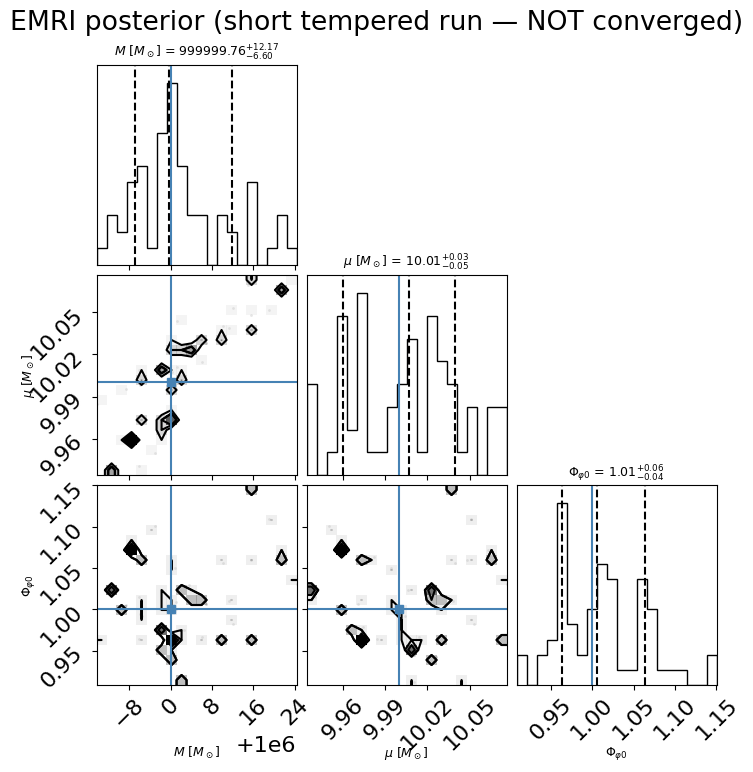

In [11]:
# clear
import corner
labels = [r"$M$ [$M_\odot$]", r"$\mu$ [$M_\odot$]", r"$\Phi_{\varphi 0}$"]
fig = corner.corner(samples, labels=labels, truths=truth3,
                    show_titles=True, title_kwargs={"fontsize": 9},
                    label_kwargs={"fontsize": 9}, quantiles=[0.16, 0.5, 0.84])
fig.suptitle("EMRI posterior (short tempered run — NOT converged)", y=1.02)
plt.show()

### Question: EMRI parameter richness & degeneracies

We sampled only 3 of the EMRI's ~14 parameters. List what the full set is,
and describe where the strong correlations live &mdash; and why an EMRI is
nonetheless one of LISA's most information-rich sources.

*Discussion.* The full 14-parameter basis is `[M, mu, a, p0, e0, xI0, dist, qS,
phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]`: two masses, the primary **spin**
$a$, the initial orbit (semi-latus rectum $p_0$, eccentricity $e_0$, inclination
$x_{I0}$), the luminosity **distance**, the sky angles $(q_S,\phi_S)$, the spin
orientation $(q_K,\phi_K)$, and three initial orbital **phases**. Because the
long, multi-harmonic phasing depends on the strong-field dynamics, the *intrinsic*
parameters $(M,\mu,a,p_0,e_0)$ are measured astonishingly well but are also
**correlated along the inspiral**: many nearby $(M,\mu,a)$ combinations track almost
the same frequency evolution over a finite baseline, and $e_0,p_0$ trade off through
the harmonic content. The *extrinsic* parameters degenerate the way every LISA
source does &mdash; distance with inclination (both set the amplitude), and both
with the sky position and polarization (which set how $h_+,h_\times$ project into
XYZ). What breaks these is exactly the response's year-long **amplitude/phase
modulation** (Task 2) plus the sheer number of harmonics, each adding an independent
constraint. That is why a single well-measured EMRI can pin masses and spin to
fractional precisions of 10&#8315;&#8308;&ndash;10&#8315;&#8310; &mdash; and why the
posterior is so sharp that sampling it is hard.

### Question: what makes EMRI inference hard?

Even with the skeleton identical to the GB case, EMRI inference is much
harder. From what you saw in this notebook, why?

*Discussion.* Three reasons compound. (1) **Cost per template.** Each likelihood
call generates a long, many-harmonic waveform *and* pushes it through the LISA
response &mdash; ~2 s here, versus the sub-millisecond band-limited GB template of
[`X6`](X6_GalacticBinaryMCMC.ipynb). A real EMRI spans a year of data with far more
modes, so templates are dramatically more expensive, which is the whole motivation
for the fast/heterodyned likelihoods and GPU waveforms in the stock fit. (2) **A
razor-sharp, structured likelihood.** The precision that makes EMRIs valuable also
makes the posterior a tiny, curved sliver in a high-dimensional space &mdash; a
blind sampler almost never lands on it, and the many harmonics create a rugged
likelihood surface riddled with secondary maxima (dephased by an integer cycle in
one harmonic). That is why we started in a *tight ball* and used *tempering*, and why
production EMRI pipelines lean on informed proposals, tempering ladders, and careful
search. (3) **Dimensionality & long baselines.** ~14 correlated parameters over
~10&#8309; orbits mean the phase must stay coherent across the entire observation, so
even small waveform-model errors or step sizes destroy the overlap. Short chain,
expensive-and-sharp likelihood, many correlated dimensions: the EMRI is the same
skeleton, running against a much steeper problem.

### Where this goes next

You have now run the full **source-MCMC skeleton** on an EMRI: an
`EMRITDIWaveform` injection &rarr; the LISA response &amp; TDI &rarr; a band-limited
`signal_gen` &rarr; an `AnalysisContainer` likelihood &rarr; a tempered sampler and a
corner plot. It is the *same* skeleton as [`X6`](X6_GalacticBinaryMCMC.ipynb)'s
galactic binary &mdash; only the waveform and its parameter transforms changed. The
distance from here to a real EMRI analysis is not a new idea about the sampler but
*scale*: all ~14 parameters, a fast/heterodyned likelihood, GPU waveforms, tuned
proposals, and a proper search to seed it (informational notebooks
[`05`](../../05_ErynSmallToLarge.ipynb) and
[`07`](../../07_StockGlobalFitsInDepth.ipynb)).